In [16]:
# %pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import kmrf as kmrf

%matplotlib inline

In [17]:
classification_dir = 'original'  # Specify the classification directory here
asset_class_dir = 'us_equity'    # Specify the asset class directory here

In [18]:
# List available saved KMRF models for specified classification and asset class
saved_models_dir = Path(f'saved_models/KMRF/{classification_dir}_labels/{asset_class_dir}')

if saved_models_dir.exists():
    saved_models_list = list(saved_models_dir.glob('*.pkl'))

    if saved_models_list:
        saved_models_list = sorted(saved_models_list)
        print(f"Available saved models in '{saved_models_dir}':\n")
        for i, model_path in enumerate(saved_models_list):
            print(f" index = {i}: {model_path.name}")
    else:
        print(f"No saved models found in '{saved_models_dir}'. Train a model first!")

Available saved models in 'saved_models/KMRF/original_labels/us_equity':

 index = 0: KMRF_Consumer-Discretionary-Select-Sector-SPDR_20190101_boruta.pkl
 index = 1: KMRF_Consumer-Staples-Select-Sector-SPDR_20190101_boruta.pkl
 index = 2: KMRF_Energy-Select-Sector-SPDR_20190101_boruta.pkl
 index = 3: KMRF_Financial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 4: KMRF_Health-Care-Select-Sector-SPDR_20190101_boruta.pkl
 index = 5: KMRF_Industrial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 6: KMRF_Invesco-QQQ-Trust_20190101_boruta.pkl
 index = 7: KMRF_Materials-Select-Sector-SPDR_20190101_boruta.pkl
 index = 8: KMRF_SPDR-Dow-Jones-Industrial-Average-ETF_20190101_boruta.pkl
 index = 9: KMRF_SPDR-S&P-500-ETF_20190101_boruta.pkl
 index = 10: KMRF_Technology-Select-Sector-SPDR_20190101_boruta.pkl
 index = 11: KMRF_Utilities-Select-Sector-SPDR_20190101_boruta.pkl
 index = 12: KMRF_iShares-Micro-Cap-ETF_20190101_boruta.pkl
 index = 13: KMRF_iShares-Russell-2000-ETF_20190101_boruta.pkl
 i

In [19]:
model_index = 1
kmrf_model = kmrf.KMRF.load_model(saved_models_list[model_index])
display(kmrf_model)
print('Dropped Features during Boruta Selection:')
print(set(kmrf_model.features.columns).union(set(kmrf_model.features.columns)) - set(kmrf_model.selected_features))

KMRF model initialized
  Asset: Consumer Staples Select Sector SPDR
  Asset class: us_equity
  Classification type: original
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-02-01 00:00:00 to 2021-12-31 00:00:00
  Test start: 2022-02-01 00:00:00
  Random seed: 1010


KMRF('us_equity, Consumer Staples Select Sector SPDR')
Raw OHLC Data (6752, 4): 1998-12-22 to 2025-10-24
Technical Features (6752, 95): 1998-12-22 to 2025-10-24
Macro Features (6752, 28): 1998-12-22 to 2025-10-24
Train (4785, 114): 1999-12-23 to 2018-12-31
Val (736, 114): 2019-02-01 to 2021-12-31
Test (937, 114): 2022-02-01 to 2025-10-24

Dropped Features during Boruta Selection:
{'log_ret_intraday_lag1d', 'open_to_close_lag1d', 'tsfresh_close_lag1d__length', 'skew_20d_lag1d', 'log_ret_overnight', 'tsfresh_volume_lag1d__length', 'log_ret_lag1d'}



Generating predictions...
  Input shape: (736, 114)
  Using pre-selected features: 114
✓ Generated probability predictions: (736, 3)


KeyError: 'P(HV_Bull)'

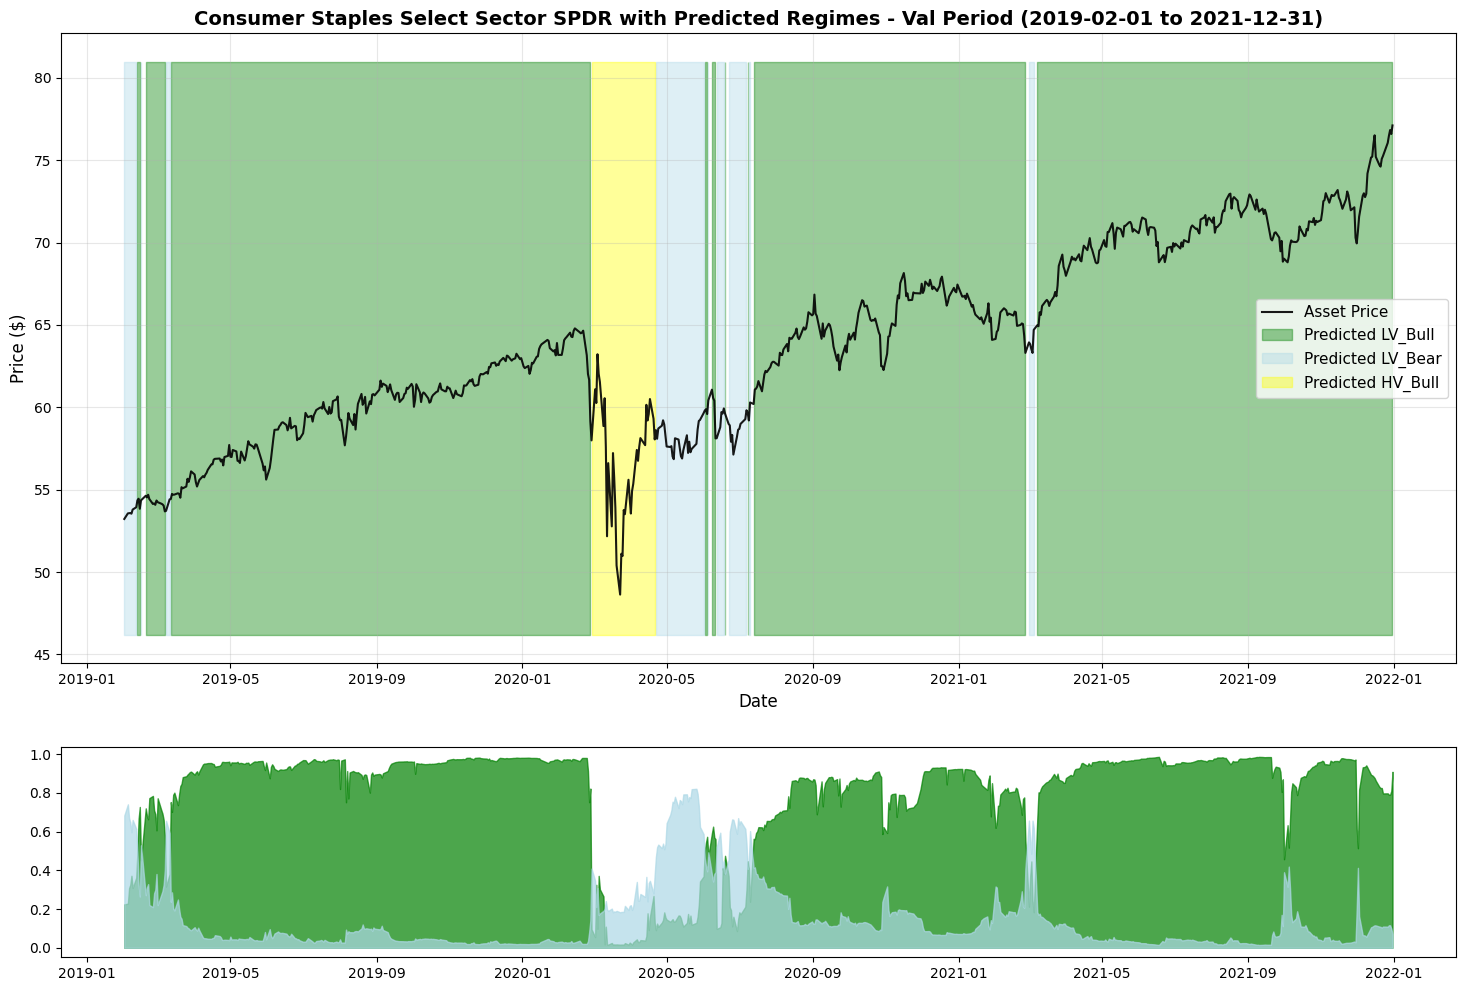

In [20]:
kmrf_model.predict(test_or_val='val')
kmrf_model.viz_predictions(test_or_val='val')

In [24]:
kmrf_model.y_val_proba

,P(LV_Bull),P(LV_Bear),P(HV_Bear)
date,,,
2019-02-01,0.223936,0.683384,0.092679
2019-02-04,0.227828,0.740661,0.031510
2019-02-05,0.307628,0.669574,0.022799
2019-02-06,0.325226,0.648402,0.026372
2019-02-07,0.371746,0.596380,0.031874
...,...,...,...
2021-12-27,0.797352,0.108825,0.093822
2021-12-28,0.789946,0.116232,0.093822
2021-12-29,0.790444,0.115733,0.093822



Generating predictions...
  Input shape: (937, 114)
  Using pre-selected features: 114
✓ Generated probability predictions: (937, 3)


KeyError: 'P(HV_Bull)'

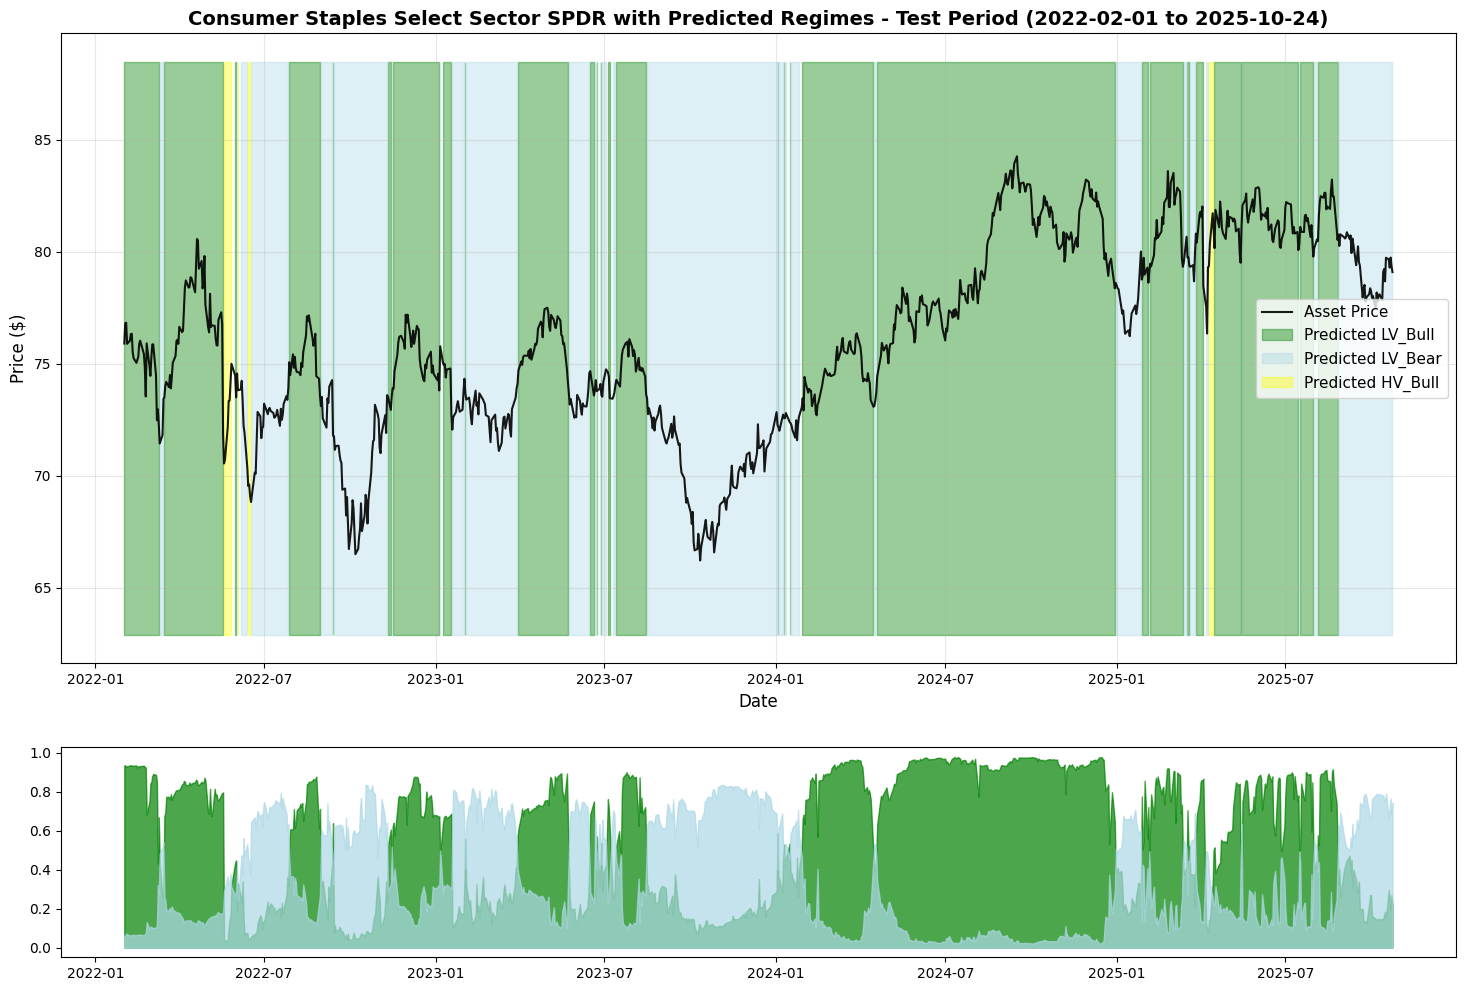

In [25]:
kmrf_model.predict(test_or_val='test')
kmrf_model.viz_predictions(test_or_val='test')